In [131]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("./data/all_perth_310121.csv")
df

,ADDRESS,SUBURB,PRICE,BEDROOMS,BATHROOMS,GARAGE,LAND_AREA,FLOOR_AREA,BUILD_YEAR,CBD_DIST,NEAREST_STN,NEAREST_STN_DIST,DATE_SOLD,POSTCODE,LATITUDE,LONGITUDE,NEAREST_SCH,NEAREST_SCH_DIST,NEAREST_SCH_RANK
0,1 Acorn Place,South Lake,565000,4,2,2.0,600,160,2003.0,18300,Cockburn Central Station,1800,09-2018\r,6164,-32.115900,115.842450,LAKELAND SENIOR HIGH SCHOOL,0.828339,NaN
1,1 Addis Way,Wandi,365000,3,2,2.0,351,139,2013.0,26900,Kwinana Station,4900,02-2019\r,6167,-32.193470,115.859554,ATWELL COLLEGE,5.524324,129.0
2,1 Ainsley Court,Camillo,287000,3,1,1.0,719,86,1979.0,22600,Challis Station,1900,06-2015\r,6111,-32.120578,115.993579,KELMSCOTT SENIOR HIGH SCHOOL,1.649178,113.0
3,1 Albert Street,Bellevue,255000,2,1,2.0,651,59,1953.0,17900,Midland Station,3600,07-2018\r,6056,-31.900547,116.038009,SWAN VIEW SENIOR HIGH SCHOOL,1.571401,NaN
4,1 Aman Place,Lockridge,325000,4,1,2.0,466,131,1998.0,11200,Bassendean Station,2000,11-2016\r,6054,-31.885790,115.947780,KIARA COLLEGE,1.514922,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33651,9C Gold Street,South Fremantle,1040000,4,3,2.0,292,245,2013.0,16100,Fremantle Station,1500,03-2016\r,6162,-32.064580,115.751820,CHRISTIAN BROTHERS' COLLEGE,1.430350,49.0
33652,9C Pycombe Way,Westminster,410000,3,2,2.0,228,114,NaN,9600,Stirling Station,4600,02-2017\r,6061,-31.867055,115.841403,JOHN SEPTIMUS ROE ANGLICAN COMMUNITY SCHOOL,1.679644,35.0
33653,9D Pycombe Way,Westminster,427000,3,2,2.0,261,112,NaN,9600,Stirling Station,4600,02-2017\r,6061,-31.866890,115.841418,JOHN SEPTIMUS ROE ANGLICAN COMMUNITY SCHOOL,1.669159,35.0
33654,9D Shalford Way,Girrawheen,295000,3,1,2.0,457,85,1974.0,12600,Warwick Station,4400,10-2016\r,6064,-31.839680,115.842410,GIRRAWHEEN SENIOR HIGH SCHOOL,0.358494,NaN


In [132]:
# Normalize column names to lowercase and drop columns not useful for prediction:
# address/suburb (too granular / high-cardinality text), station/school names (replaced by distance features),
# lat/lon (spatial info captured by cbd_dist), and school rank (too many nulls)
df.rename(columns=lambda x: x.lower(), inplace=True)
df.drop(columns=["address", "suburb", "nearest_stn", "latitude", "longitude", "nearest_sch", "nearest_sch_rank"], inplace=True)
df

,price,bedrooms,bathrooms,garage,land_area,floor_area,build_year,cbd_dist,nearest_stn_dist,date_sold,postcode,nearest_sch_dist
0,565000,4,2,2.0,600,160,2003.0,18300,1800,09-2018\r,6164,0.828339
1,365000,3,2,2.0,351,139,2013.0,26900,4900,02-2019\r,6167,5.524324
2,287000,3,1,1.0,719,86,1979.0,22600,1900,06-2015\r,6111,1.649178
3,255000,2,1,2.0,651,59,1953.0,17900,3600,07-2018\r,6056,1.571401
4,325000,4,1,2.0,466,131,1998.0,11200,2000,11-2016\r,6054,1.514922
...,...,...,...,...,...,...,...,...,...,...,...,...
33651,1040000,4,3,2.0,292,245,2013.0,16100,1500,03-2016\r,6162,1.430350
33652,410000,3,2,2.0,228,114,NaN,9600,4600,02-2017\r,6061,1.679644
33653,427000,3,2,2.0,261,112,NaN,9600,4600,02-2017\r,6061,1.669159
33654,295000,3,1,2.0,457,85,1974.0,12600,4400,10-2016\r,6064,0.358494


In [133]:
# Check for missing values across all columns, then inspect garage distribution.
# Note: max of 99 garages is likely a data entry error — median imputation is safer than mean here.
df.isnull().sum()
df['garage'].describe()

count    31178.000000
mean         2.199917
std          1.365225
min          1.000000
25%          2.000000
50%          2.000000
75%          2.000000
max         99.000000
Name: garage, dtype: float64

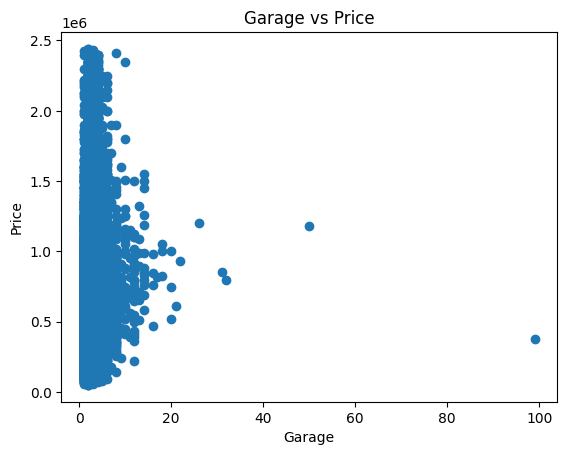

In [134]:
# Visualize garage count vs sale price to check for outliers and understand the relationship
plt.scatter(df["garage"], df["price"])
plt.xlabel("Garage")
plt.ylabel("Price")
plt.title("Garage vs Price")
plt.show()

In [135]:
# Replace missing garage values with the median (2 garages) — robust to the outlier at 99
df.fillna({'garage': df['garage'].median().astype(int)}, inplace=True)

,price,bedrooms,bathrooms,garage,land_area,floor_area,build_year,cbd_dist,nearest_stn_dist,date_sold,postcode,nearest_sch_dist
0,565000,4,2,2.0,600,160,2003.0,18300,1800,09-2018\r,6164,0.828339
1,365000,3,2,2.0,351,139,2013.0,26900,4900,02-2019\r,6167,5.524324
2,287000,3,1,1.0,719,86,1979.0,22600,1900,06-2015\r,6111,1.649178
3,255000,2,1,2.0,651,59,1953.0,17900,3600,07-2018\r,6056,1.571401
4,325000,4,1,2.0,466,131,1998.0,11200,2000,11-2016\r,6054,1.514922
...,...,...,...,...,...,...,...,...,...,...,...,...
33651,1040000,4,3,2.0,292,245,2013.0,16100,1500,03-2016\r,6162,1.430350
33652,410000,3,2,2.0,228,114,NaN,9600,4600,02-2017\r,6061,1.679644
33653,427000,3,2,2.0,261,112,NaN,9600,4600,02-2017\r,6061,1.669159
33654,295000,3,1,2.0,457,85,1974.0,12600,4400,10-2016\r,6064,0.358494


In [136]:
# Inspect build_year distribution to choose an appropriate imputation strategy
df['build_year'].describe()

count    30501.000000
mean      1989.706436
std         20.964330
min       1868.000000
25%       1978.000000
50%       1995.000000
75%       2005.000000
max       2017.000000
Name: build_year, dtype: float64

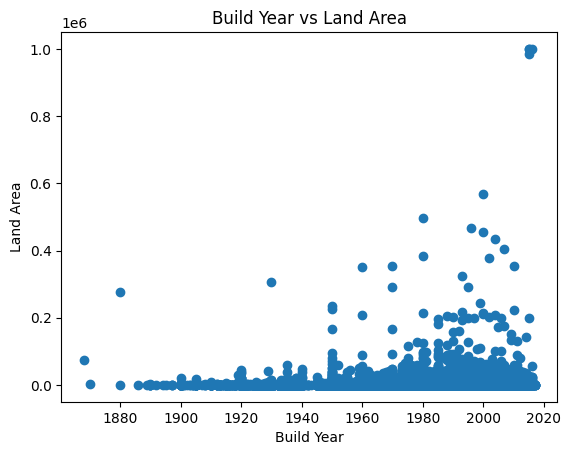

In [137]:
# Scatter plot to explore how build year relates to land area (newer builds tend to have smaller plots)
plt.scatter(df['build_year'], df["land_area"])
plt.xlabel("Build Year")
plt.ylabel("Land Area")
plt.title("Build Year vs Land Area")
plt.show()

In [138]:
# Replace missing build_year with the median (1995) — avoids skew from early 1900s outliers
df.fillna({'build_year': df['build_year'].median().astype(int)}, inplace=True)

,price,bedrooms,bathrooms,garage,land_area,floor_area,build_year,cbd_dist,nearest_stn_dist,date_sold,postcode,nearest_sch_dist
0,565000,4,2,2.0,600,160,2003.0,18300,1800,09-2018\r,6164,0.828339
1,365000,3,2,2.0,351,139,2013.0,26900,4900,02-2019\r,6167,5.524324
2,287000,3,1,1.0,719,86,1979.0,22600,1900,06-2015\r,6111,1.649178
3,255000,2,1,2.0,651,59,1953.0,17900,3600,07-2018\r,6056,1.571401
4,325000,4,1,2.0,466,131,1998.0,11200,2000,11-2016\r,6054,1.514922
...,...,...,...,...,...,...,...,...,...,...,...,...
33651,1040000,4,3,2.0,292,245,2013.0,16100,1500,03-2016\r,6162,1.430350
33652,410000,3,2,2.0,228,114,1995.0,9600,4600,02-2017\r,6061,1.679644
33653,427000,3,2,2.0,261,112,1995.0,9600,4600,02-2017\r,6061,1.669159
33654,295000,3,1,2.0,457,85,1974.0,12600,4400,10-2016\r,6064,0.358494


In [139]:
# Confirm no remaining null values — dataset is now clean and ready for modeling
df.isnull().sum()

price               0
bedrooms            0
bathrooms           0
garage              0
land_area           0
floor_area          0
build_year          0
cbd_dist            0
nearest_stn_dist    0
date_sold           0
postcode            0
nearest_sch_dist    0
dtype: int64

In [140]:
df.to_csv("./data/preprocessed_perth.csv", index=False)